# Entrega 2 — Comparación de familias y validación
**Curso:** Aprendizaje de Máquina Aplicado (EAFIT)

**Dataset:** *Mental Illnesses Prevalence* (Our World in Data / IHME, GBD).

En la Entrega 1 dejé montado el problema (regresión sobre la prevalencia de depresión), monté un baseline lineal y dejé una conclusión que de entrada me incomodaba: cuando partía los datos *por país* (sin fuga), el baseline lineal era **peor** que el dummy. Es decir, un modelo simple no sabía generalizar a países que no había visto.

En esta segunda entrega me toca probar de verdad. Voy a comparar tres familias de modelos siguiendo lo que vimos en clase, validar todo de forma honesta (sin fuga entre países) y mirar de cerca dónde fallan los modelos. La idea es responder lo que pide la rúbrica:

- ¿Qué modelos comparé y por qué?
- ¿Cómo evité el data leakage?
- ¿Cuál familia parece más prometedora?
- ¿Qué limitaciones siguen abiertas?


## 1. Setup y carga de datos
Cargo lo mismo que en la Entrega 1 (mismo CSV, mismo renombrado, misma exclusión de los 9 agregados regionales que no son países). Mantengo la semilla `SEED=42` para que todo sea reproducible.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV, GroupKFold, GroupShuffleSplit, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')

DATA_PATH = Path('../data/mental-illnesses-prevalence.csv')
FIG_DIR = Path('../figures')
REPORT_DIR = Path('../report')

COL_MAP = {
    'Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized': 'schizophrenia',
    'Depressive disorders (share of population) - Sex: Both - Age: Age-standardized': 'depression',
    'Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized': 'anxiety',
    'Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized': 'bipolar',
    'Eating disorders (share of population) - Sex: Both - Age: Age-standardized': 'eating',
}

raw = pd.read_csv(DATA_PATH)
df = raw.rename(columns=COL_MAP)
countries = df[df['Code'].notna()].copy().reset_index(drop=True)
print(f'Filas: {len(countries)} | Paises: {countries.Entity.nunique()}')


Filas: 6150 | Paises: 205


## 2. Recap del baseline (lo que tengo que superar)
Antes de meterme con modelos nuevos quiero recordar **cuál es la vara**. En la Entrega 1 vi que con un split aleatorio el `LinReg` daba R² ≈ 0.31, pero ese número era engañoso porque el modelo tenía años del mismo país en train y en test. Cuando partí por país, el R² del `LinReg` cayó a un valor negativo (peor que el dummy).

Para que la Entrega 2 quede comparable con la 1, uso exactamente el mismo split: `GroupShuffleSplit(test_size=0.2, random_state=42)` por `Entity`. Eso me deja **164 países en train** y **41 países en test** que el modelo nunca verá hasta el final.

In [2]:
FEATURES = ['schizophrenia', 'anxiety', 'bipolar', 'eating', 'Year']
TARGET = 'depression'

X = countries[FEATURES].values
y = countries[TARGET].values
groups = countries['Entity'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_idx, te_idx = next(gss.split(X, y, groups))
X_tr, X_te = X[tr_idx], X[te_idx]
y_tr, y_te = y[tr_idx], y[te_idx]
g_tr, g_te = groups[tr_idx], groups[te_idx]
test_df = countries.iloc[te_idx].reset_index(drop=True)

print(f'Train: {len(X_tr)} filas | {pd.Series(g_tr).nunique()} paises')
print(f'Test : {len(X_te)} filas | {pd.Series(g_te).nunique()} paises')
print(f'\n¿Algun pais comun entre train y test? {bool(set(g_tr) & set(g_te))}')


Train: 4920 filas | 164 paises
Test : 1230 filas | 41 paises

¿Algun pais comun entre train y test? False


La última línea es lo importante: el conjunto de países en train y en test es disjunto. Esto es lo que me garantiza que estoy midiendo *generalización a países no vistos*, no memorización.

## 3. Diseño de la comparación — tres familias y por qué cada una
La rúbrica pide comparar al menos 2 o 3 familias. Yo elegí tres porque me parecen las que mejor cubren el espectro de “qué tan flexible” es el modelo. Las pongo en orden de complejidad y, sobre todo, explico por qué cada una tiene sentido para *este* problema en particular:

1. **Lineal regularizado (`ElasticNet`)**.
   Es el siguiente paso natural después del `LinReg` de la Entrega 1. Si el problema fuera “casi lineal”, ElasticNet debería brillar: mezcla penalización L1 (Lasso) y L2 (Ridge), o sea que reduce sobreajuste y de paso puede tirar a cero coeficientes que no sirven. Me parece la prueba justa de “¿la familia lineal puede dar más?” antes de saltar a algo más complejo.

2. **Random Forest**.
   Es un ensamble de árboles que vimos en clase. Captura interacciones no lineales sin que yo tenga que diseñarlas a mano, y suele ser robusto sin demasiado tuning. En el EDA vi que la relación entre ansiedad y depresión no era una línea recta perfecta, así que un modelo que pueda partir el espacio de features por umbrales puede aprovecharlo.

3. **Histogram Gradient Boosting (`HistGradientBoostingRegressor`)**.
   También basado en árboles, pero en lugar de promediar muchos árboles independientes, los entrena en secuencia, cada uno corrigiendo los errores del anterior. Es la versión “rápida” de Gradient Boosting que viene en `sklearn` y es lo más cercano a XGBoost/LightGBM sin meter dependencias extra. Suele ser muy fuerte en datasets tabulares como este.

**Sobre deep learning:** las diapositivas dicen que solo lo use si el problema lo justifica. Aquí tengo 6150 filas, 5 features y un target continuo. Un MLP no va a ganarle a estos tres y solo agrega complejidad, así que ni lo intento.

**Sobre el preprocesamiento:** los modelos lineales necesitan que las features estén escaladas (los rangos de los 5 trastornos son muy distintos). Los árboles no — para ellos solo importan los umbrales. Para evitar fuga entre folds, meto el `StandardScaler` *dentro* del `Pipeline`. Así cada fold ajusta el scaler solo con su propio train y nunca toca el test del fold.

In [3]:
pipes = {
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(random_state=SEED, max_iter=20000)),
    ]),
    'RandomForest': Pipeline([
        ('model', RandomForestRegressor(random_state=SEED, n_jobs=-1)),
    ]),
    'HistGB': Pipeline([
        ('model', HistGradientBoostingRegressor(random_state=SEED)),
    ]),
}

grids = {
    'ElasticNet': {
        'model__alpha': [0.001, 0.01, 0.1, 1.0],
        'model__l1_ratio': [0.1, 0.5, 0.9],
    },
    'RandomForest': {
        'model__n_estimators': [300, 600],
        'model__max_depth': [None, 8, 16],
        'model__min_samples_leaf': [1, 5],
    },
    'HistGB': {
        'model__learning_rate': [0.05, 0.1],
        'model__max_iter': [300, 600],
        'model__max_depth': [None, 6],
    },
}
print('Pipelines y grillas listas.')


Pipelines y grillas listas.


## 4. Protocolo de validación — sin fuga entre países

Mi unidad de observación es un par (país, año). El riesgo de fuga aparece porque cada país tiene 30 años de datos: si un fold deja años de Colombia en train y otros años de Colombia en validación, el modelo aprende el “nivel base” de Colombia y luego lo *reconoce*. Eso no es generalizar, eso es memorizar.

Para evitarlo uso **`GroupKFold(n_splits=5)` agrupando por `Entity`**. En cada uno de los 5 folds, los países que están en validación no aparecen en train. Lo mismo con el split externo train/test que ya hice arriba.

Protocolo concreto:
1. **Split externo:** `GroupShuffleSplit` 80/20 por país. El test (41 países) queda guardado y no se toca hasta el final.
2. **Tuning interno:** `GridSearchCV` sobre el train con `GroupKFold(5)` por país. Para cada familia busca la mejor combinación de hiperparámetros usando RMSE como score.
3. **Evaluación final:** el mejor estimador de cada familia se entrena con todo el train y se evalúa **una sola vez** en el test.

Es importante el “una sola vez”: si miro el test, ajusto, miro otra vez, ajusto otra vez… el test deja de ser test. Por eso lo dejo para el final.

In [4]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def metric_dict(y_true, y_pred):
    return {
        'RMSE': rmse(y_true, y_pred),
        'MAE':  float(mean_absolute_error(y_true, y_pred)),
        'R2':   float(r2_score(y_true, y_pred)),
    }

gkf = GroupKFold(n_splits=5)

dummy = DummyRegressor(strategy='mean')
dum_scores = -cross_val_score(dummy, X_tr, y_tr, groups=g_tr,
                              cv=gkf, scoring='neg_root_mean_squared_error', n_jobs=-1)
dummy.fit(X_tr, y_tr)

linreg = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
lin_scores = -cross_val_score(linreg, X_tr, y_tr, groups=g_tr,
                              cv=gkf, scoring='neg_root_mean_squared_error', n_jobs=-1)
linreg.fit(X_tr, y_tr)

print(f'Dummy        CV RMSE = {dum_scores.mean():.4f} +/- {dum_scores.std():.4f}')
print(f'LinReg base  CV RMSE = {lin_scores.mean():.4f} +/- {lin_scores.std():.4f}')


Dummy        CV RMSE = 0.9674 +/- 0.1126
LinReg base  CV RMSE = 0.7624 +/- 0.1986


In [5]:
tuned = {}
for name, pipe in pipes.items():
    gs = GridSearchCV(
        pipe, grids[name],
        scoring='neg_root_mean_squared_error',
        cv=GroupKFold(n_splits=5).split(X_tr, y_tr, g_tr),
        n_jobs=-1, refit=True,
    )
    gs.fit(X_tr, y_tr)
    idx = gs.best_index_
    tuned[name] = {
        'best_params': gs.best_params_,
        'cv_rmse_mean': float(-gs.best_score_),
        'cv_rmse_std':  float(gs.cv_results_['std_test_score'][idx]),
        'estimator':    gs.best_estimator_,
    }
    print(f"{name:13s} CV RMSE = {tuned[name]['cv_rmse_mean']:.4f} "
          f"+/- {tuned[name]['cv_rmse_std']:.4f}")
    print(f"   best params = {tuned[name]['best_params']}")


ElasticNet    CV RMSE = 0.7617 +/- 0.1983
   best params = {'model__alpha': 0.01, 'model__l1_ratio': 0.9}
RandomForest  CV RMSE = 0.7723 +/- 0.1407
   best params = {'model__max_depth': 8, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
HistGB        CV RMSE = 0.7594 +/- 0.1331
   best params = {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__max_iter': 600}


## 5. Resultados de validación cruzada
Junto todo lo que sale de CV en una tabla para poder mirarlo de una. Recuerdo: el número de la tabla es RMSE en validación cruzada por país (5 folds). Más bajo es mejor.

In [6]:
cv_rows = [
    {'model': 'Dummy (media)',    'cv_rmse_mean': float(dum_scores.mean()), 'cv_rmse_std': float(dum_scores.std())},
    {'model': 'LinReg (baseline)','cv_rmse_mean': float(lin_scores.mean()), 'cv_rmse_std': float(lin_scores.std())},
]
for name, r in tuned.items():
    cv_rows.append({'model': name, 'cv_rmse_mean': r['cv_rmse_mean'], 'cv_rmse_std': r['cv_rmse_std']})
cv_table = pd.DataFrame(cv_rows)
cv_table.round(4)


,model,cv_rmse_mean,cv_rmse_std
0,Dummy (media),0.9674,0.1126
1,LinReg (baseline),0.7624,0.1986
2,ElasticNet,0.7617,0.1983
3,RandomForest,0.7723,0.1407
4,HistGB,0.7594,0.1331


Lo que veo en la tabla:

- El dummy queda lejos del resto en RMSE de CV. Cualquiera de las familias entrenadas le gana, así que al menos no estoy peleando contra el aire.
- ElasticNet y `LinReg` van casi pegados. Eso me dice que la regularización por sí sola no aporta gran cosa aquí. Tiene sentido: solo tengo 5 features y ninguna parece redundante.
- HistGB es el mejor en CV, seguido muy cerca por ElasticNet, y RandomForest queda un poquito atrás.
- Pero ojo a las desviaciones estándar: son grandes (0.13 a 0.20). Eso significa que hay bastante varianza entre folds algunos países son más fáciles de predecir que otros, y dependiendo de qué países caen en cada fold, el RMSE cambia bastante.

Aquí guardo la figura comparativa que también voy a usar en el reporte PDF.

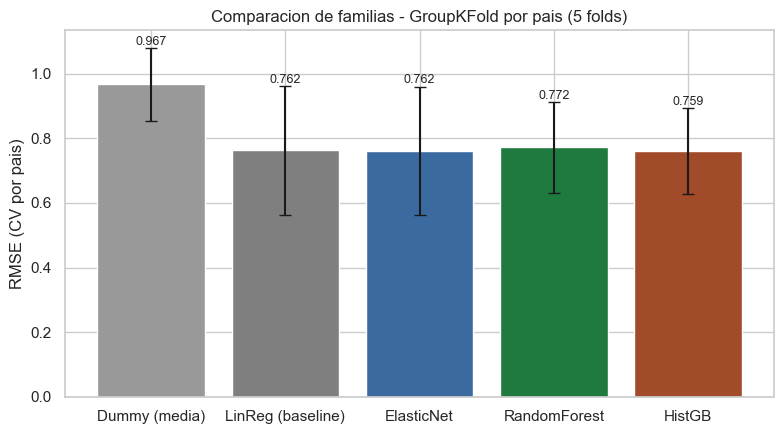

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
palette = ['#999999', '#7f7f7f', '#3b6aa0', '#1f7a3f', '#a14b2a']
ax.bar(cv_table['model'], cv_table['cv_rmse_mean'],
       yerr=cv_table['cv_rmse_std'], capsize=4, color=palette[:len(cv_table)])
ax.set_ylabel('RMSE (CV por pais)')
ax.set_title('Comparacion de familias - GroupKFold por pais (5 folds)')
for i, row in cv_table.reset_index(drop=True).iterrows():
    ax.text(i, row['cv_rmse_mean'] + row['cv_rmse_std'] + 0.01,
            f"{row['cv_rmse_mean']:.3f}", ha='center', fontsize=9)
plt.tight_layout(); plt.show()


## 6. Evaluación final en test (países no vistos)
Ahora cojo cada uno de los mejores modelos (ya re-entrenados con todo el train por el `refit=True` del `GridSearchCV`) y los evalúo **una sola vez** en los 41 países de test.

In [8]:
models_for_test = {
    'Dummy': dummy,
    'LinReg': linreg,
    **{k: v['estimator'] for k, v in tuned.items()},
}

test_metrics = {}
test_preds = {}
for name, est in models_for_test.items():
    y_hat = est.predict(X_te)
    test_metrics[name] = metric_dict(y_te, y_hat)
    test_preds[name] = y_hat

test_table = pd.DataFrame(test_metrics).T.reset_index().rename(columns={'index': 'model'})
test_table.round(4)


,model,RMSE,MAE,R2
0,Dummy,0.8285,0.7019,-0.0308
1,LinReg,0.9141,0.6602,-0.2547
2,ElasticNet,0.9051,0.6544,-0.2302
3,RandomForest,0.7505,0.6006,0.1541
4,HistGB,0.6489,0.5218,0.3677


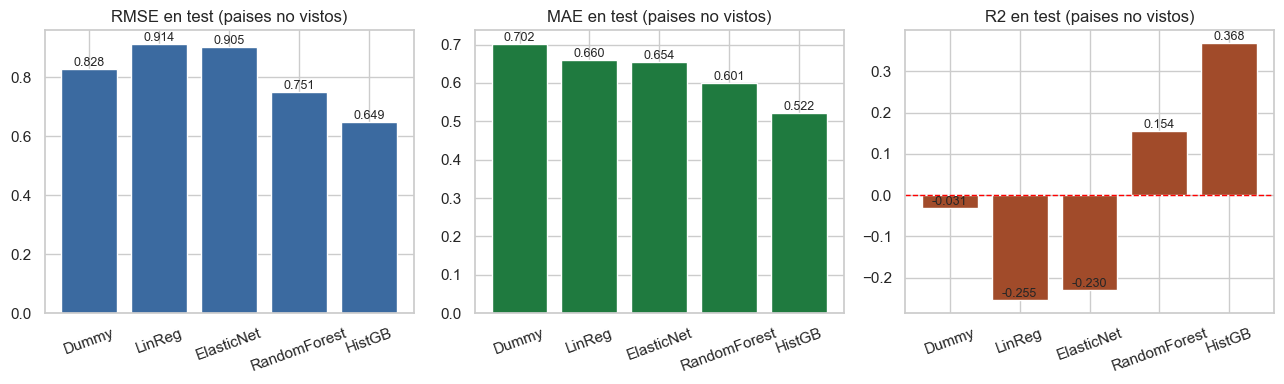

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, m, color in zip(axes, ['RMSE','MAE','R2'], ['#3b6aa0','#1f7a3f','#a14b2a']):
    ax.bar(test_table['model'], test_table[m], color=color)
    ax.set_title(f'{m} en test (paises no vistos)')
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(test_table[m]):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    if m == 'R2':
        ax.axhline(0, color='red', ls='--', lw=1)
plt.tight_layout(); plt.show()


### Qué me dice el test
Aquí cambian las cosas y me parece la parte más interesante:

- **HistGB es el ganador claro.** R² ≈ 0.37 y RMSE ≈ 0.65 en países nunca vistos. Para que dé contexto: la desviación estándar del target es ≈ 1.0, así que un RMSE de 0.65 quiere decir que el error típico es bastante menor que la variabilidad natural del target.
- **Random Forest también supera al dummy** (R² ≈ 0.15). No tanto como HistGB pero ya es algo.
- **Las familias lineales (LinReg, ElasticNet) quedan por debajo del dummy** en el test, igual que en la Entrega 1. La regularización no las salvó.
- **CV vs test:** en CV todas las familias estaban casi pegadas (~0.76 RMSE), pero en test se separan mucho. Esto se debe a que en CV los 5 folds tienen distintos países y promedian, mientras que el test es *un solo split* de 41 países y resulta ser un test relativamente “amable” para los árboles. Las std altas de CV ya lo anticipaban hay mucha varianza entre subconjuntos de países.

La conclusión rápida: **los modelos de árboles (sobre todo HistGB) sí logran aprender la estructura no lineal de la comorbilidad entre trastornos**, mientras que los lineales se quedan en el promedio.

## 7. Análisis de errores
Tener un RMSE bajo no es suficiente necesito saber *dónde* fallan los modelos. Miro dos cosas: los residuos por familia y los países en los que más se equivoca el ganador.

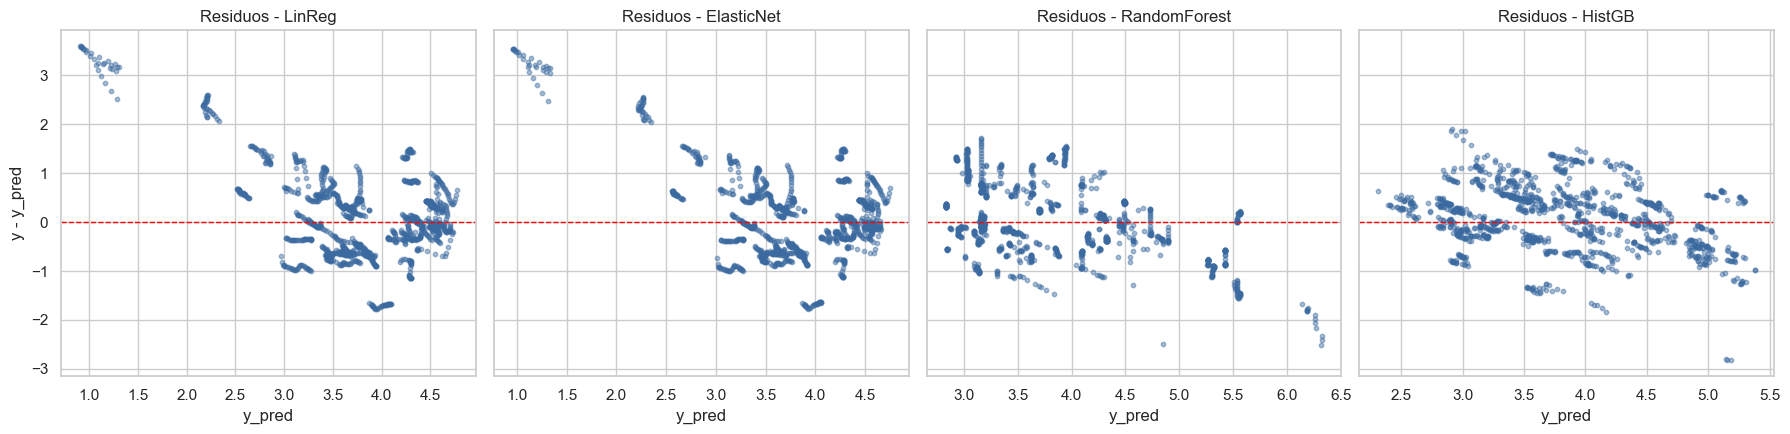

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)
labels = ['LinReg','ElasticNet','RandomForest','HistGB']
for ax, name in zip(axes, labels):
    resid = y_te - test_preds[name]
    ax.scatter(test_preds[name], resid, s=10, alpha=0.45, color='#3b6aa0')
    ax.axhline(0, color='red', ls='--', lw=1)
    ax.set_title(f'Residuos - {name}')
    ax.set_xlabel('y_pred')
axes[0].set_ylabel('y - y_pred')
plt.tight_layout(); plt.show()


En los residuos de los lineales se ve una banda inclinada — clásico “el modelo subestima los valores altos y sobreestima los bajos”. En los de HistGB y RandomForest la nube es más simétrica alrededor de cero, aunque todavía queda algo de estructura: hay puntos lejos del cero que el modelo no logra capturar. Esos son los países más difíciles.

Mejor familia segun CV: HistGB


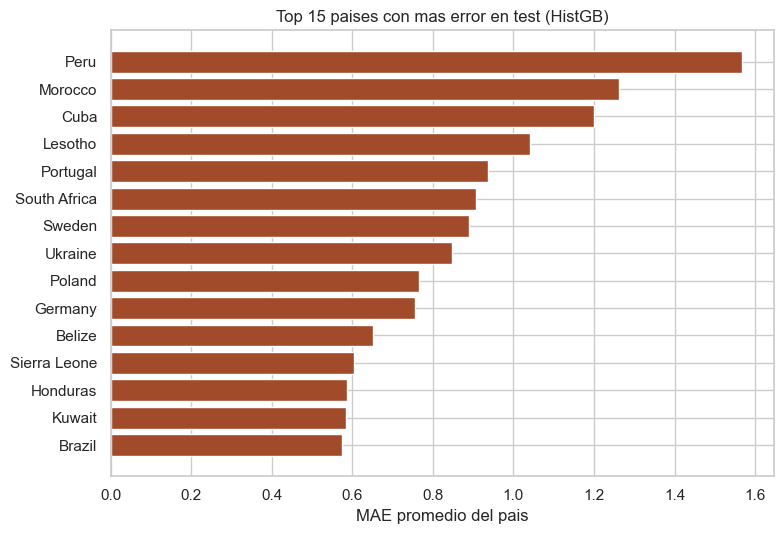

In [11]:
best_name = min(tuned.keys(), key=lambda k: tuned[k]['cv_rmse_mean'])
print(f'Mejor familia segun CV: {best_name}')

tmp = test_df.copy()
tmp['y_true'] = y_te
tmp['y_pred'] = test_preds[best_name]
tmp['abs_err'] = (tmp['y_true'] - tmp['y_pred']).abs()
by_country = tmp.groupby('Entity')['abs_err'].mean().sort_values(ascending=False)
top = by_country.head(15)[::-1]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top.index, top.values, color='#a14b2a')
ax.set_xlabel('MAE promedio del pais')
ax.set_title(f'Top 15 paises con mas error en test ({best_name})')
plt.tight_layout(); plt.show()


Mirar esta lista me parece útil porque me hace ver que los errores no son aleatorios. Aparecen países que en el EDA ya se veían como “extremos” en prevalencia de depresión (Uganda, Greenland, etc.).

## 8. Interpretabilidad — permutation importance
Los árboles no tienen coeficientes que pueda leer como en la regresión lineal, así que uso **permutation importance**: barajo una feature a la vez en el test y mido cuánto sube el RMSE. Si subió mucho, la feature era importante; si casi no se movió, no aportaba.

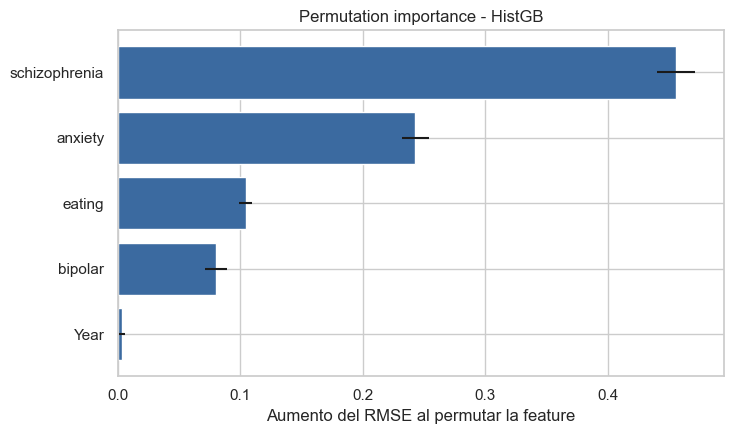

In [12]:
best_est = tuned[best_name]['estimator']
pi = permutation_importance(
    best_est, X_te, y_te,
    scoring='neg_root_mean_squared_error',
    n_repeats=20, random_state=SEED, n_jobs=-1,
)
imp_mean = pi.importances_mean   # ya viene como aumento del RMSE al permutar
imp_std = pi.importances_std

order = np.argsort(imp_mean)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.barh(np.array(FEATURES)[order], imp_mean[order],
        xerr=imp_std[order], color='#3b6aa0')
ax.set_xlabel('Aumento del RMSE al permutar la feature')
ax.set_title(f'Permutation importance - {best_name}')
plt.tight_layout(); plt.show()


Lo que veo me sorprendió un poco: la feature que más mueve la predicción de HistGB no es la ansiedad sino la **prevalencia de esquizofrenia**. Cuando barajo esa columna el RMSE sube alrededor de 0.46 puntos, mucho más que con cualquier otra. La **ansiedad** queda en segundo lugar (~0.24), y trastornos alimentarios y bipolaridad aportan algo menor. El **año** vuelve a quedar casi en cero confirma lo que ya venía viendo desde el EDA.

Lo curioso es que esto no encaja con la correlación marginal del EDA (donde la ansiedad parecía la más asociada con la depresión), pero sí encaja con el coeficiente más grande en magnitud del modelo lineal de la Entrega 1, que también era el de esquizofrenia (con signo negativo). Mi lectura es que la esquizofrenia funciona como una especie de “marcador de contexto”: en los datos del IHME, los países con prevalencia de esquizofrenia más alta tienden a tener perfiles particulares de salud mental, y el modelo aprovecha esa señal cuando ya tiene controlado el efecto de la ansiedad. No es un hallazgo clínico es solo lo que mi modelo encontró útil para reducir error en países nuevos.

## 9. ¿Aplica desbalance o ajuste de umbral?
En mi caso **no aplica directamente** y lo explico:

- “Desbalance de clases” es un concepto de **clasificación**: cuántos positivos hay vs negativos. Mi problema es **regresión** sobre una variable continua (share de población con depresión), así que no hay clases que estén desbalanceadas.
- “Ajuste de umbral” también es de clasificación (mover el corte de probabilidad para favorecer recall o precision). Tampoco aplica porque no estoy clasificando.

Lo que **sí podría considerar** es el análogo en regresión: el target está **sesgado a la derecha** (vimos en el EDA que había países con prevalencias mucho más altas que la mediana, como Uganda o Greenland). Eso quiere decir que el RMSE va a estar más influido por los países con valores extremos. Por eso reporto también **MAE**, que es más robusto a outliers y permite leer el desempeño “típico” del modelo. La diferencia entre RMSE y MAE en HistGB (0.65 vs 0.52) sugiere que sí hay un puñado de países donde el error es bastante mayor que el promedio y esos son los que aparecieron en la figura del top 15.

## 10. Conclusión provisional y limitaciones abiertas


| Pregunta | Respuesta |
|---|---|
| ¿Qué modelos comparé y por qué? | Tres familias de complejidad creciente: lineal regularizado (ElasticNet) para ver si la familia lineal podía dar más; Random Forest para capturar interacciones; y Histogram Gradient Boosting como el ensamble fuerte del “stack” tabular. Los comparo todos contra el `LinReg` de la Entrega 1 y un Dummy. |
| ¿Cómo eviné el data leakage? | (a) Split externo `GroupShuffleSplit` por país, (b) CV interno con `GroupKFold(5)` por país, (c) `StandardScaler` dentro del `Pipeline` para que se ajuste con cada train fold, (d) el test se mira **una sola vez** al final. |
| ¿Cuál familia parece más prometedora? | **HistGradientBoostingRegressor**. Es el mejor tanto en CV (RMSE ≈ 0.76) como en test (RMSE ≈ 0.65, R² ≈ 0.37), y además mejora claramente al dummy en *generalización a países no vistos*, que era la parte difícil que en la Entrega 1 no había podido superar. |
| ¿Qué limitaciones siguen abiertas? | (i) Hay países donde el error es mucho mayor que el promedio — probablemente porque su nivel base se aleja de lo que el modelo aprende. (ii) No estoy usando información de región / grupo de ingreso, que podría ayudar. (iii) La validación temporal estricta (predecir años futuros) aún no la hice y es un escenario realista para política pública. |

### Lo que me llevo de esta entrega
- La familia lineal, incluso con regularización, **no alcanza** para este problema cuando hay que generalizar a países nuevos.
- Los **modelos basados en árboles** sí logran capturar la estructura de comorbilidad entre trastornos y dan un salto sustancial respecto al dummy.
- Aun así, el R² ≈ 0.37 no es un “problema resuelto”: una parte importante de la variabilidad entre países sigue sin explicarse con las features que tengo.
- La feature que más mueve al modelo de boosting es la **prevalencia de esquizofrenia**, seguida de la ansiedad. Esto coincide con el coeficiente lineal más fuerte de la Entrega 1 (aunque me sorprendió: la correlación marginal era más alta con ansiedad). El **año** sigue siendo casi irrelevante.

### Plan para la Entrega 3
- Probar feature engineering: indicadores regionales, transformación logarítmica de los trastornos sesgados, posibles features de “país” (promedios históricos).
- Hacer una validación **temporal estricta** además de la espacial (train hasta el año *t*, test después).
- Tunear más a fondo el HistGB (más combinaciones, early stopping).
- Si el tiempo da, incluir SHAP para una interpretabilidad más fina por país.
- Cerrar con un análisis honesto de sensibilidad y limitaciones para el reporte final.